<a href="https://colab.research.google.com/github/ariafcode/Regional-analysis-of-non-HDL-to-HDL-cholesterol-ratios/blob/main/Regional_analysis_of_non_HDL_to_HDL_cholesterol_ratios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Data Science/NCD_RisC_Nature_2020_Cholesterol_age_standardised_countries.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.lower()
df_clean.columns = df_clean.columns.str.replace(" ", "_")
df_clean.columns = df_clean.columns.str.replace("(", "").str.replace(")", "").str.replace("/", "_")

In [5]:
df_regions=pd.read_csv('/content/drive/MyDrive/Data Science/ncd_region_map.csv')
df_merged = pd.merge(
    df_clean,
    df_regions,
    left_on="country_region_world",
    right_on="country",
    how="left"
)
df_merged['super_region'] = df_merged['super_region'].astype(str).str.strip()
print(df_merged['super_region'].unique())

['South Asia' 'Central and Eastern Europe'
 'Central Asia, Middle East, and North Africa' 'Oceania'
 'High-income Western' 'Sub-Saharan Africa' 'Latin America and Caribbean'
 'East and Southeast Asia' 'High-income Asia Pacific']


In [6]:
df_1980_merged = df_merged[df_merged['year'] == 1980].copy()
df_2018_merged = df_merged[df_merged['year'] == 2018].copy()
df_initial_hdl_regional = df_1980_merged.groupby('super_region')['mean_hdl_cholesterol_mmol_l'].mean()
df_final_hdl_regional = df_2018_merged.groupby('super_region')['mean_hdl_cholesterol_mmol_l'].mean()
change_in_mean_HDL_regional = df_final_hdl_regional - df_initial_hdl_regional
df_initial_nonhdl_regional = df_1980_merged.groupby('super_region')['mean_non-hdl_cholesterol_mmol_l'].mean()
df_final_nonhdl_regional = df_2018_merged.groupby('super_region')['mean_non-hdl_cholesterol_mmol_l'].mean()
change_in_mean_non_HDL_regional = df_final_nonhdl_regional - df_initial_nonhdl_regional

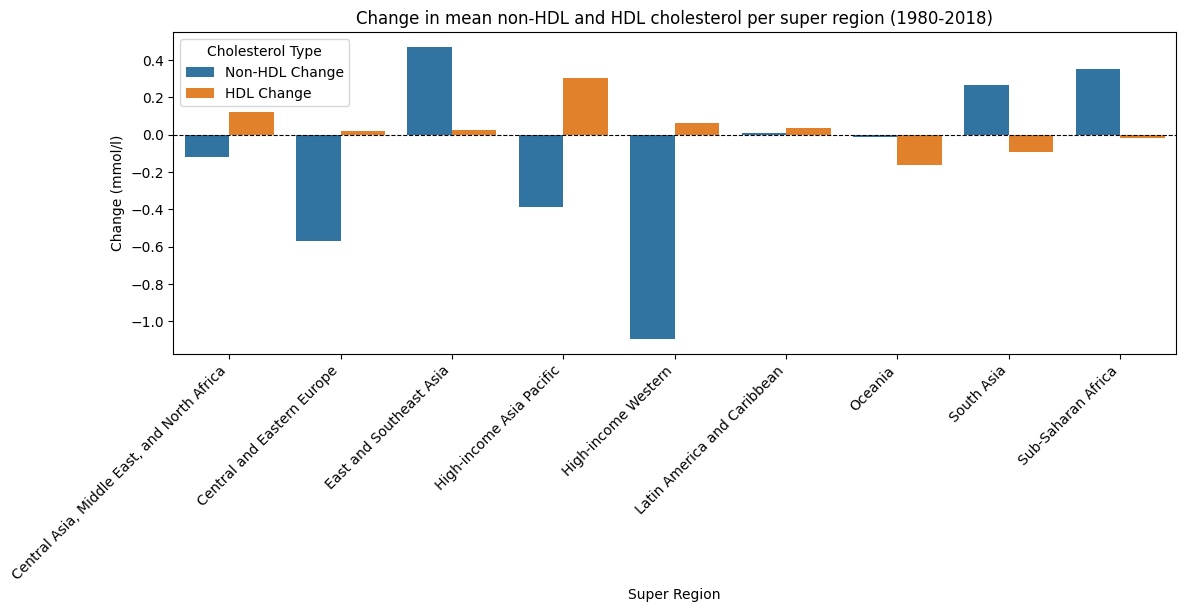

In [7]:
#Figure 1. Comparison of change in non-HDl and HDL cholesterol
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = pd.DataFrame({
    'Non-HDL Change': change_in_mean_non_HDL_regional,
    'HDL Change': change_in_mean_HDL_regional
}).reset_index()

df_melted = df_plot.melt(
    id_vars='super_region',
    value_vars=['Non-HDL Change', 'HDL Change'],
    var_name='Cholesterol Type',
    value_name='Change (mmol/l)'
)
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_melted,
    x='super_region',
    y='Change (mmol/l)',
    hue='Cholesterol Type'
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel('Super Region')
plt.title('Change in mean non-HDL and HDL cholesterol per super region (1980-2018)')
plt.show()

In [8]:
df_1980_merged['ratio_of_non-HDL_to_HDL'] = df_1980_merged['mean_non-hdl_cholesterol_mmol_l']/df_1980_merged['mean_hdl_cholesterol_mmol_l']
df_2018_merged['ratio_of_non-HDL_to_HDL'] = df_2018_merged['mean_non-hdl_cholesterol_mmol_l']/df_2018_merged['mean_hdl_cholesterol_mmol_l']

ratio_1980_regional = df_1980_merged.groupby('super_region')['ratio_of_non-HDL_to_HDL'].mean()
ratio_2018_regional = df_2018_merged.groupby('super_region')['ratio_of_non-HDL_to_HDL'].mean()

percentage_change_regional = ((ratio_2018_regional - ratio_1980_regional) /ratio_1980_regional)*100
percentage_change_regional = percentage_change_regional.sort_values(ascending=False)

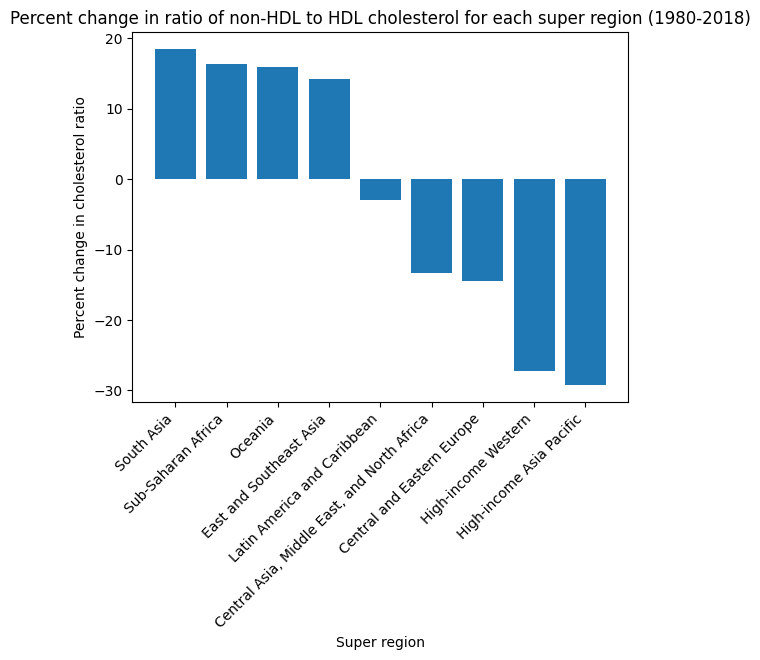

<Figure size 640x480 with 0 Axes>

In [9]:
#Figure 2. Percent change in NHHR (1980-2018)
plt.bar(percentage_change_regional.index, percentage_change_regional.values)

plt.xlabel('Super region')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percent change in cholesterol ratio')
plt.title('Percent change in ratio of non-HDL to HDL cholesterol for each super region (1980-2018)')

plt.show()

plt.savefig('percentage_change.png')

Backtesting Performance
Low-Middle-Income


ValueError: Found input variables with inconsistent numbers of samples: [8, 17]

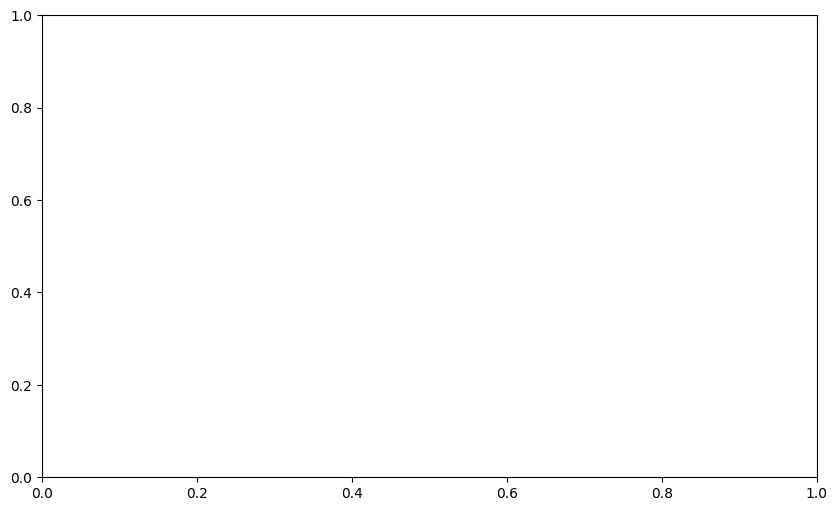

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
fig, ax = plt.subplots(figsize=(10, 6))

df_merged['ratio_of_non-HDL_to_HDL'] = df_merged['mean_non-hdl_cholesterol_mmol_l']/df_merged['mean_hdl_cholesterol_mmol_l']
regions = df_merged['super_region'].unique()

high_income_regions = ["High-income Western", "High-income Asia Pacific"]
df_merged["income_group"] = np.where(
    df_merged["super_region"].isin(high_income_regions),
    "High-Income",
    "Low-Middle-Income",
)

future_years = pd.DataFrame({"year": np.arange(2019, 2036)})
groups = df_merged["income_group"].unique()

for group in groups:
    group_df = df_merged[df_merged["income_group"] == group]

    yearly_avg = (
        group_df.groupby("year", as_index=False)["ratio_of_non-HDL_to_HDL"].mean().sort_values("year")
    )
    train_data = yearly_avg[yearly_avg["year"] <= 2010]
    test_data = yearly_avg[yearly_avg["year"] > 2010]
    X_train_backtest = train_data[["year"]]
    y_train_backtest = train_data["ratio_of_non-HDL_to_HDL"]
    X_test_backtest = future_years[["year"]]
    y_test_backtest = test_data["ratio_of_non-HDL_to_HDL"]
    backtest_model = LinearRegression()
    backtest_model.fit(X_train_backtest, y_train_backtest)
    backtest_pred = backtest_model.predict(X_test_backtest)
    print("Backtesting Performance")
    print(f"{group}")
    print("Mean Absolute Error:", mean_absolute_error(y_test_backtest, backtest_pred))
    print('R squared: ', r2_score(y_test_backtest, backtest_pred))



In [30]:
#anova and tukey
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
df_2018_merged_1 = df_merged[df_merged['year'] == 2018].copy()
groups = df_2018_merged_1.groupby('super_region')['ratio_of_non-HDL_to_HDL']
oceania = groups.get_group('Oceania').values
south_asia = groups.get_group('South Asia').values
sub_saharan_africa = groups.get_group('Sub-Saharan Africa').values
latin_america = groups.get_group('Latin America and Caribbean').values
high_income_western = groups.get_group('High-income Western').values
high_income_asia_pacific = groups.get_group('High-income Asia Pacific').values
east_and_southeast_asia = groups.get_group('East and Southeast Asia').values
central_and_eastern_europe = groups.get_group('Central and Eastern Europe').values
central_asia_middle_east_north_africa = groups.get_group('Central Asia, Middle East, and North Africa').values
result = stats.f_oneway(oceania, south_asia, sub_saharan_africa, latin_america, high_income_western, high_income_asia_pacific, east_and_southeast_asia, central_and_eastern_europe, central_asia_middle_east_north_africa)
p_val = result.pvalue
print("ANOVA P-Value:", p_val)
print("F-Statistic:", result.statistic)

tukey = pairwise_tukeyhsd(
    endog = df_2018_merged_1['ratio_of_non-HDL_to_HDL'],
    groups = df_2018_merged_1['super_region']
)
print(tukey)

ANOVA P-Value: 2.8615073641135065e-64
F-Statistic: 61.14589230167023
                             Multiple Comparison of Means - Tukey HSD, FWER=0.05                              
                   group1                              group2           meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------------------------------
Central Asia, Middle East, and North Africa  Central and Eastern Europe  -0.2492 0.0122 -0.4673  -0.031   True
Central Asia, Middle East, and North Africa     East and Southeast Asia   0.2009 0.1785 -0.0376  0.4393  False
Central Asia, Middle East, and North Africa    High-income Asia Pacific  -0.3796 0.1835 -0.8323  0.0731  False
Central Asia, Middle East, and North Africa         High-income Western  -0.4309    0.0 -0.6319 -0.2299   True
Central Asia, Middle East, and North Africa Latin America and Caribbean   0.3175    0.0  0.1285  0.5064   True
Central Asia, Middle East, and North Africa

In [31]:
#two sample t-test
import numpy as np
import pandas as pd
import scipy.stats as stats
high_income_regions = ['High-income Western', 'High-income Asia Pacific']
df_2018_merged_1['income_group'] = np.where(
    df_2018_merged_1['super_region'].isin(high_income_regions),
    'High-Income',
    'Low-Middle-Income'
)
high_inc_data = df_2018_merged_1[df_2018_merged_1['income_group'] == 'High-Income']['ratio_of_non-HDL_to_HDL'].values
low_mid_inc_data = df_2018_merged_1[df_2018_merged_1['income_group'] == 'Low-Middle-Income']['ratio_of_non-HDL_to_HDL'].values
t_stat, p_val = stats.ttest_ind(high_inc_data, low_mid_inc_data)
print("T-test P-value: ", p_val)
print("T-test T-statistic: ", t_stat)

T-test P-value:  1.3526191572654763e-14
T-test T-statistic:  -8.002057068265698


mean squared:  0.0028923013097944946
R squared:  0.8829971046238062
mean squared:  0.001213873469061024
R squared:  0.949568659265077
mean squared:  0.00021551723887487564
R squared:  0.980772818767498
mean squared:  0.00039333155574372753
R squared:  0.996100320563255
mean squared:  0.002099052462647984
R squared:  0.975865509995755
mean squared:  0.0003850332399842445
R squared:  0.8339076184149159
mean squared:  0.0019689049134993366
R squared:  0.8854306653776299
mean squared:  0.002051225127222993
R squared:  0.8986413429077642
mean squared:  0.0004848184183760043
R squared:  0.9542368008525538


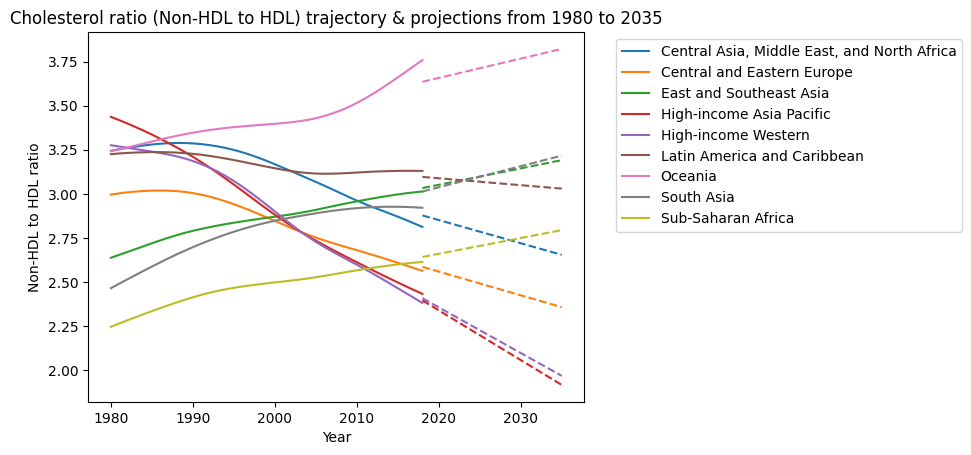

<Figure size 640x480 with 0 Axes>

In [32]:
#Figure 3. Linear Regression Model
import numpy as np
from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
regional_trends = df_merged.groupby(['super_region','year'])['ratio_of_non-HDL_to_HDL'].mean().reset_index()
future_years = np.array(range(2018, 2036)).reshape(-1, 1)
regions = regional_trends['super_region'].unique()
for region in regions:
    region_data = regional_trends[regional_trends['super_region'] == region]
    X_train = region_data['year'].values.reshape(-1, 1)
    y_train = region_data['ratio_of_non-HDL_to_HDL'].values
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    pred = lr_model.predict(future_years)
    train_preds = lr_model.predict(X_train)
    print('mean squared: ', mean_squared_error(y_train, train_preds))
    print('R squared: ', r2_score(y_train, train_preds))
    line = plt.plot(X_train, y_train, label=region)
    plt.plot(future_years, pred, linestyle='--', color=line[0].get_color())
plt.title("Cholesterol ratio (Non-HDL to HDL) trajectory & projections from 1980 to 2035")
plt.xlabel("Year")
plt.ylabel("Non-HDL to HDL ratio")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()
plt.savefig('linear_regression_model.png')